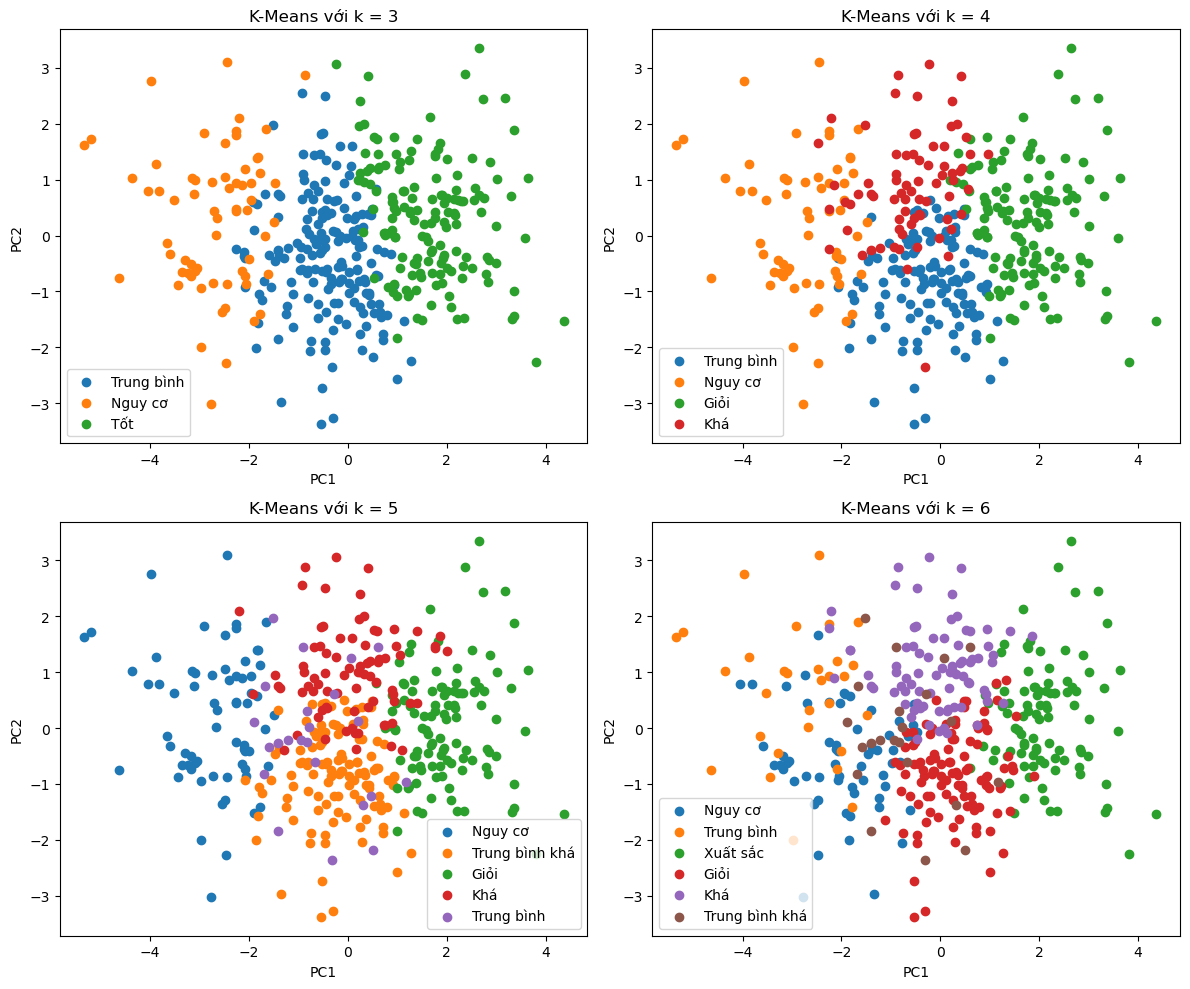

In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv', sep=',')

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA để trực quan hóa
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 5. Danh sách k
# =========================
K_values = [3, 4, 5, 6]

plt.figure(figsize=(12,10))

for i, k in enumerate(K_values):

    # =========================
    # KMeans
    # =========================
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    # thêm cột cluster
    df['Cluster'] = labels

    # =========================
    # Tính G3 trung bình
    # =========================
    mean_scores = (
        df.groupby('Cluster')['G3']
        .mean()
        .sort_values()
    )

    # =========================
    # Đặt tên cụm
    # =========================
    if k == 3:
        ten = [
            "Nguy cơ",
            "Trung bình",
            "Tốt"
        ]

    elif k == 4:
        ten = [
            "Nguy cơ",
            "Trung bình",
            "Khá",
            "Giỏi"
        ]

    elif k == 5:
        ten = [
            "Nguy cơ",
            "Trung bình",
            "Trung bình khá",
            "Khá",
            "Giỏi"
        ]

    elif k == 6:
        ten = [
            "Nguy cơ",
            "Trung bình",
            "Trung bình khá",
            "Khá",
            "Giỏi",
            "Xuất sắc"
        ]

    # =========================
    # Mapping tên cụm
    # =========================
    mapping = {}

    for idx, cluster_id in enumerate(mean_scores.index):
        mapping[cluster_id] = ten[idx]

    # gán tên cụm
    df['TenCum'] = df['Cluster'].map(mapping)

    # =========================
    # Vẽ biểu đồ
    # =========================
    plt.subplot(2, 2, i + 1)

    for label in df['TenCum'].unique():

        plt.scatter(
            X_pca[df['TenCum'] == label, 0],
            X_pca[df['TenCum'] == label, 1],
            label=label
        )

    plt.title(f'K-Means với k = {k}')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    plt.legend()

# =========================
# 6. Hiển thị
# =========================
plt.tight_layout()
plt.show()


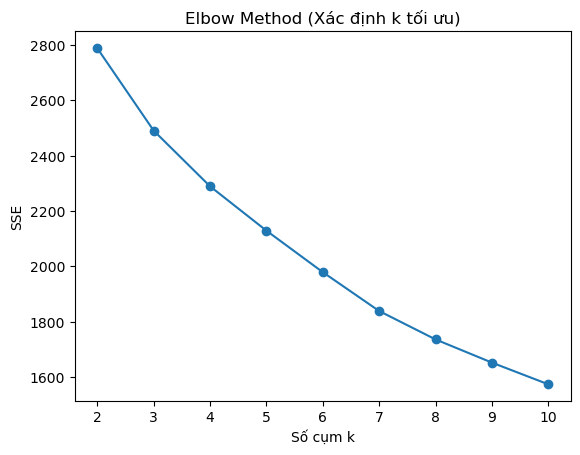

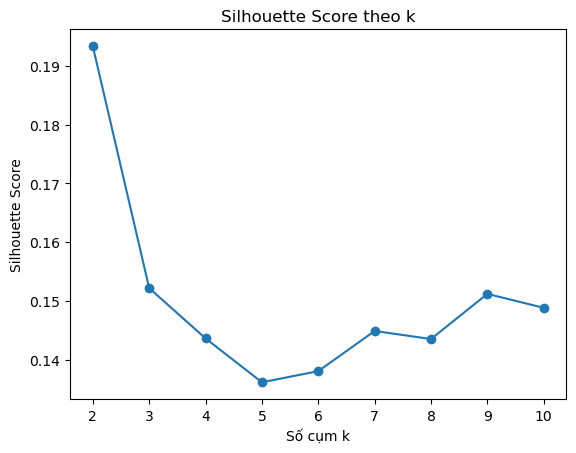


Kết quả chi tiết:
k = 2 | SSE = 2787.77 | Silhouette = 0.1933
k = 3 | SSE = 2490.36 | Silhouette = 0.1522
k = 4 | SSE = 2289.37 | Silhouette = 0.1436
k = 5 | SSE = 2129.22 | Silhouette = 0.1361
k = 6 | SSE = 1979.40 | Silhouette = 0.1380
k = 7 | SSE = 1839.07 | Silhouette = 0.1449
k = 8 | SSE = 1736.54 | Silhouette = 0.1435
k = 9 | SSE = 1652.80 | Silhouette = 0.1512
k = 10 | SSE = 1574.50 | Silhouette = 0.1488


In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv', sep=',')

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. Thử nhiều giá trị k
# =========================
K_range = range(2, 11)

sse = []
silhouette = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
 
    # SSE (Elbow)
    sse.append(kmeans.inertia_)
 
    # Silhouette
    score = silhouette_score(X_scaled, labels)
    silhouette.append(score)

# =========================
# 5. Vẽ biểu đồ Elbow
# =========================
plt.figure()
plt.plot(K_range, sse, marker='o')
plt.xlabel('Số cụm k')
plt.ylabel('SSE')
plt.title('Elbow Method (Xác định k tối ưu)')
plt.show()

# =========================
# 6. Vẽ biểu đồ Silhouette
# =========================
plt.figure()
plt.plot(K_range, silhouette, marker='o')
plt.xlabel('Số cụm k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score theo k')
plt.show()

# =========================
# 7. In kết quả
# =========================
print("\nKết quả chi tiết:")
for i in range(len(K_range)):
    print(f"k = {K_range[i]} | SSE = {sse[i]:.2f} | Silhouette = {silhouette[i]:.4f}")

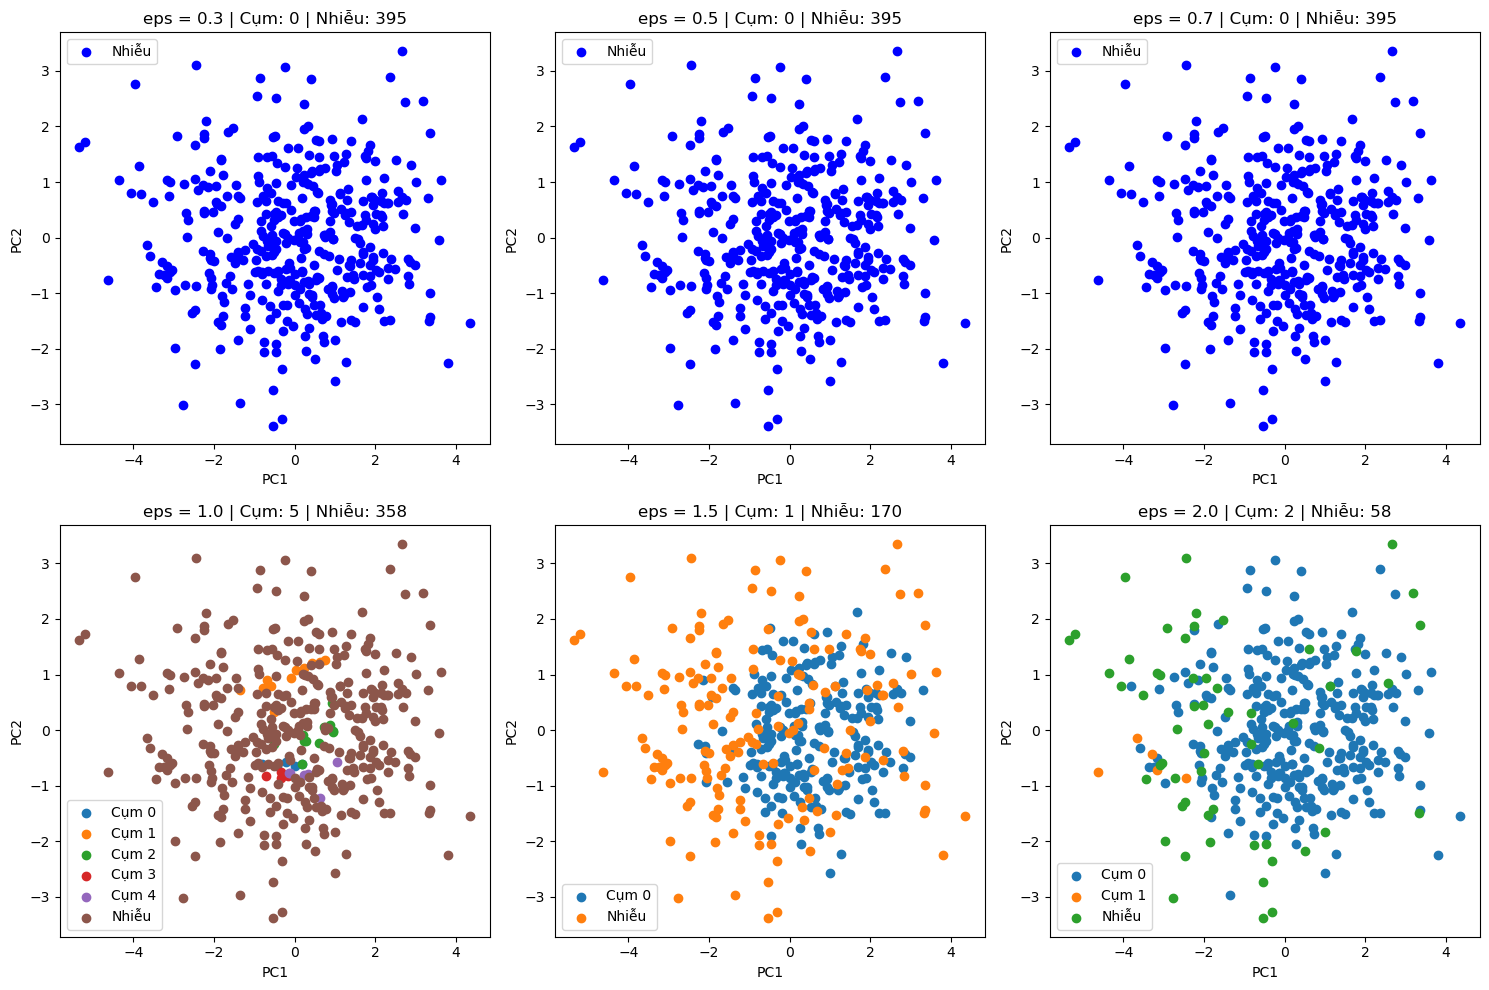

In [10]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv', sep=',')

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA để trực quan hóa
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 5. Thử nhiều giá trị eps
# =========================
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]

# cố định min_samples
min_samples = 5

# =========================
# 6. Vẽ biểu đồ
# =========================
plt.figure(figsize=(15,10))

for i, eps in enumerate(eps_values):

    # Khởi tạo DBSCAN
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    # Phân cụm
    labels = dbscan.fit_predict(X_scaled)

    # Đếm số cụm (không tính nhiễu)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Đếm số điểm nhiễu
    noise = list(labels).count(-1)

    # Tạo subplot
    plt.subplot(2, 3, i + 1)

    unique_labels = set(labels)

    # Vẽ từng cụm
    for label in unique_labels:

        # Nếu là nhiễu
        if label == -1:
            
            name = 'Nhiễu'
        else:
            color = None
            name = f'Cụm {label}'

        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            c=color,
            label=name
        )

    # Tiêu đề
    plt.title(
        f'eps = {eps} | '
        f'Cụm: {n_clusters} | '
        f'Nhiễu: {noise}'
    )

    plt.xlabel('PC1')
    plt.ylabel('PC2')

    plt.legend()

# =========================
# 7. Hiển thị
# =========================
plt.tight_layout()
plt.show()

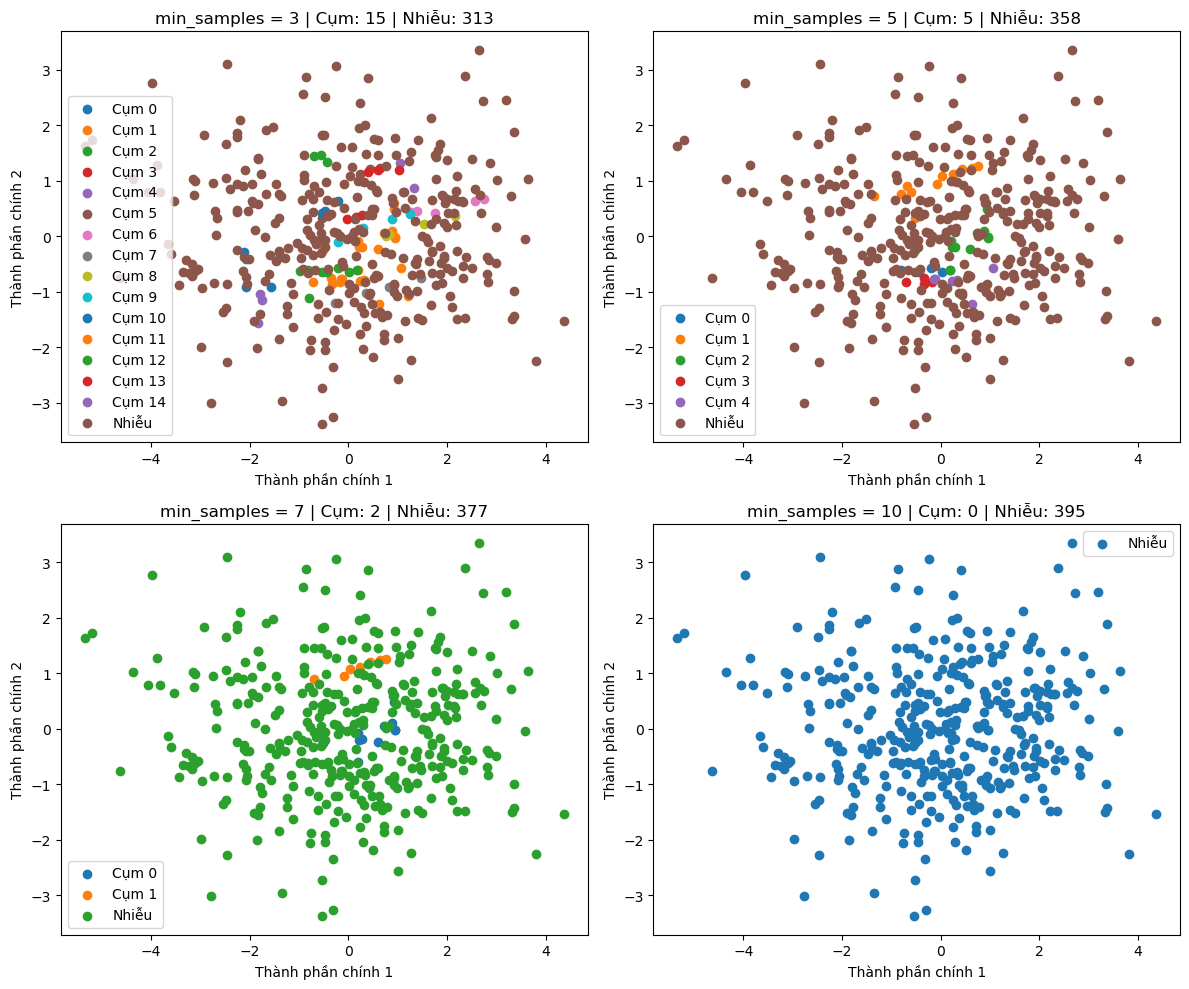

In [24]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv', sep=',')

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 3. Chuẩn hóa
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA để vẽ
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 5. Thử nhiều min_samples
# =========================
eps = 1.0  # giữ cố định 
min_samples_list = [3, 5, 7, 10]

plt.figure(figsize=(12,10))

for i, min_s in enumerate(min_samples_list):

    dbscan = DBSCAN(eps=eps, min_samples=min_s)
    labels = dbscan.fit_predict(X_scaled)

    # số cụm
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # số nhiễu
    noise = list(labels).count(-1)

    # vẽ
    plt.subplot(2, 2, i+1)

    for label in set(labels):
        if label == -1:
            name = 'Nhiễu'
        else:
            name = f'Cụm {label}'

        plt.scatter(
            X_pca[labels == label, 0],
            X_pca[labels == label, 1],
            label=name
        )

    plt.title(f'min_samples = {min_s} | Cụm: {n_clusters} | Nhiễu: {noise}')
    plt.xlabel('Thành phần chính 1')
    plt.ylabel('Thành phần chính 2')
    plt.legend()

plt.tight_layout()
plt.show()

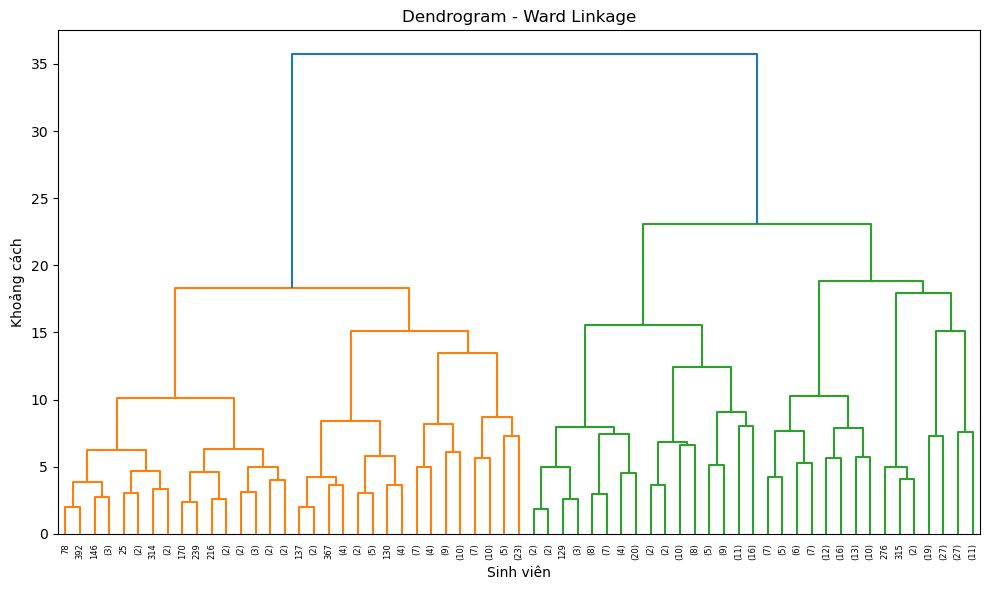

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# =========================
# Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv')

# =========================
# Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# Ward Linkage
# =========================
Z = linkage(X_scaled, method='ward')

# =========================
# Vẽ Dendrogram
# =========================
plt.figure(figsize=(10,6))

dendrogram(
    Z,
    truncate_mode='level',
    p=5
)

plt.title('Dendrogram - Ward Linkage')
plt.xlabel('Sinh viên')
plt.ylabel('Khoảng cách')

plt.tight_layout()
plt.show()

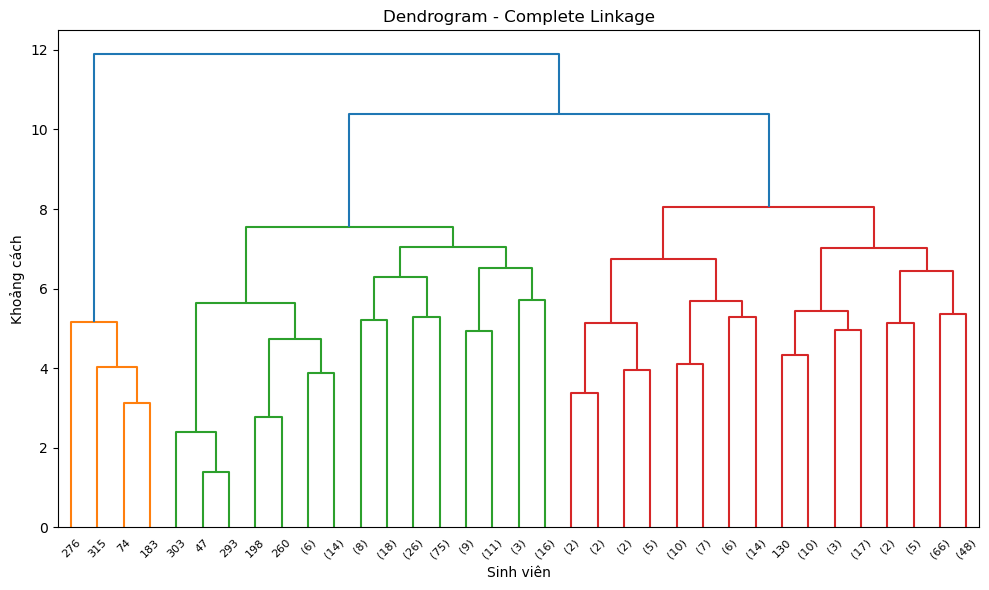

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Đọc dữ liệu
df = pd.read_csv(r'E:/student-mat.csv')

# Chọn thuộc tính
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Complete Linkage
Z = linkage(X_scaled, method='complete')

# Vẽ
plt.figure(figsize=(10,6))

dendrogram(
    Z,
    truncate_mode='level',
    p=5
)

plt.title('Dendrogram - Complete Linkage')
plt.xlabel('Sinh viên')
plt.ylabel('Khoảng cách')

plt.tight_layout()
plt.show()

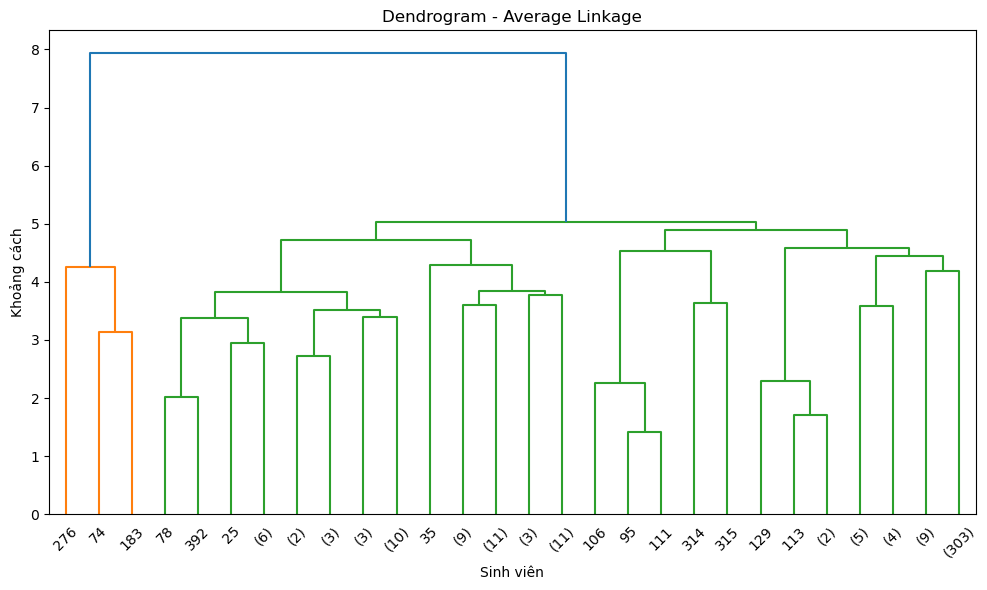

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# Đọc dữ liệu
df = pd.read_csv(r'E:/student-mat.csv')

# Chọn thuộc tính
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Average Linkage
Z = linkage(X_scaled, method='average')

# Vẽ
plt.figure(figsize=(10,6))

dendrogram(
    Z,
    truncate_mode='level',
    p=5
)

plt.title('Dendrogram - Average Linkage')
plt.xlabel('Sinh viên')
plt.ylabel('Khoảng cách')

plt.tight_layout()
plt.show()

E:\ANCONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


========== KẾT QUẢ ==========

K-Means
Silhouette Score      : 0.1522
Davies-Bouldin Index  : 1.9466
Calinski-Harabasz     : 83.7908

DBSCAN
Silhouette Score      : 0.2686
Davies-Bouldin Index  : 1.0301
Calinski-Harabasz     : 19.8737

Hierarchical (Ward)
Silhouette Score      : 0.0966
Davies-Bouldin Index  : 2.3455
Calinski-Harabasz     : 66.8763


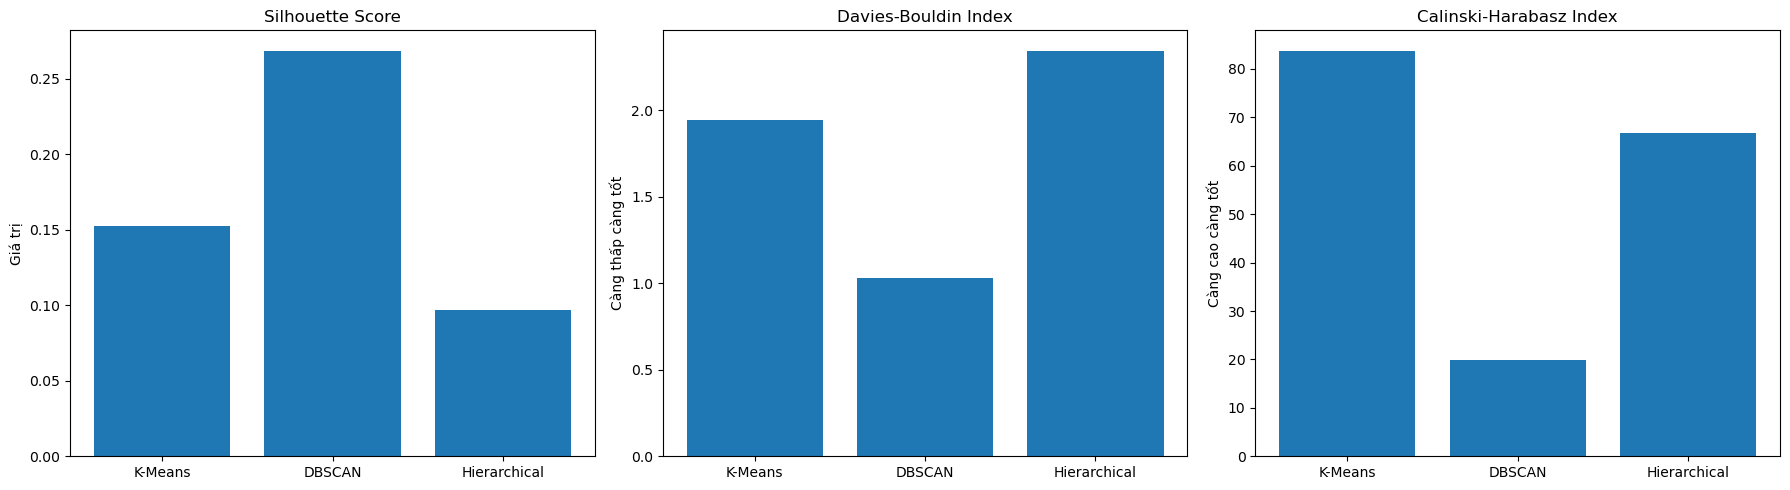

In [14]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r"E:/student-mat.csv")

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# K-MEANS (k=3)
# ==================================================
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(
    X_scaled,
    labels_kmeans
)

db_kmeans = davies_bouldin_score(
    X_scaled,
    labels_kmeans
)

ch_kmeans = calinski_harabasz_score(
    X_scaled,
    labels_kmeans
)

# ==================================================
# DBSCAN (eps=1.0, min_samples=3)
# ==================================================
dbscan = DBSCAN(
    eps=1.0,
    min_samples=3
)

labels_dbscan = dbscan.fit_predict(X_scaled)

# Loại bỏ nhiễu (-1)
mask = labels_dbscan != -1

X_db = X_scaled[mask]
labels_db = labels_dbscan[mask]

n_clusters_db = len(set(labels_db))

if n_clusters_db >= 2:

    sil_dbscan = silhouette_score(
        X_db,
        labels_db
    )

    db_dbscan = davies_bouldin_score(
        X_db,
        labels_db
    )

    ch_dbscan = calinski_harabasz_score(
        X_db,
        labels_db
    )

else:

    sil_dbscan = 0
    db_dbscan = 0
    ch_dbscan = 0

# ==================================================
# HIERARCHICAL (WARD)
# ==================================================
hier = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels_hier = hier.fit_predict(X_scaled)

sil_hier = silhouette_score(
    X_scaled,
    labels_hier
)

db_hier = davies_bouldin_score(
    X_scaled,
    labels_hier
)

ch_hier = calinski_harabasz_score(
    X_scaled,
    labels_hier
)

# ==================================================
# IN KẾT QUẢ
# ==================================================
print("========== KẾT QUẢ ==========")

print("\nK-Means")
print("Silhouette Score      :", round(sil_kmeans, 4))
print("Davies-Bouldin Index  :", round(db_kmeans, 4))
print("Calinski-Harabasz     :", round(ch_kmeans, 4))

print("\nDBSCAN")
print("Silhouette Score      :", round(sil_dbscan, 4))
print("Davies-Bouldin Index  :", round(db_dbscan, 4))
print("Calinski-Harabasz     :", round(ch_dbscan, 4))

print("\nHierarchical (Ward)")
print("Silhouette Score      :", round(sil_hier, 4))
print("Davies-Bouldin Index  :", round(db_hier, 4))
print("Calinski-Harabasz     :", round(ch_hier, 4))

# ==================================================
# BIỂU ĐỒ SO SÁNH
# ==================================================
algorithms = [
    "K-Means",
    "DBSCAN",
    "Hierarchical"
]

sil_scores = [
    sil_kmeans,
    sil_dbscan,
    sil_hier
]

db_scores = [
    db_kmeans,
    db_dbscan,
    db_hier
]

ch_scores = [
    ch_kmeans,
    ch_dbscan,
    ch_hier
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

# -------------------------
# Silhouette Score
# -------------------------
axes[0].bar(
    algorithms,
    sil_scores
)

axes[0].set_title(
    "Silhouette Score"
)

axes[0].set_ylabel(
    "Giá trị"
)

# -------------------------
# Davies-Bouldin
# -------------------------
axes[1].bar(
    algorithms,
    db_scores
)

axes[1].set_title(
    "Davies-Bouldin Index"
)

axes[1].set_ylabel(
    "Càng thấp càng tốt"
)

# -------------------------
# Calinski-Harabasz
# -------------------------
axes[2].bar(
    algorithms,
    ch_scores
)

axes[2].set_title(
    "Calinski-Harabasz Index"
)

axes[2].set_ylabel(
    "Càng cao càng tốt"
)

plt.tight_layout()
plt.show()


===== THỐNG KÊ TRUNG BÌNH CÁC CỤM =====
               G1     G2     G3  failures  absences  studytime
TenCum                                                        
Học tốt     14.30  14.27  14.46      0.10      4.39       2.11
Nguy cơ      7.17   5.71   4.09      1.51      4.32       1.60
Trung bình   9.38   9.51   9.27      0.11      7.34       2.13

===== SỐ LƯỢNG SINH VIÊN =====
TenCum
Trung bình    178
Học tốt       152
Nguy cơ        65
Name: count, dtype: int64


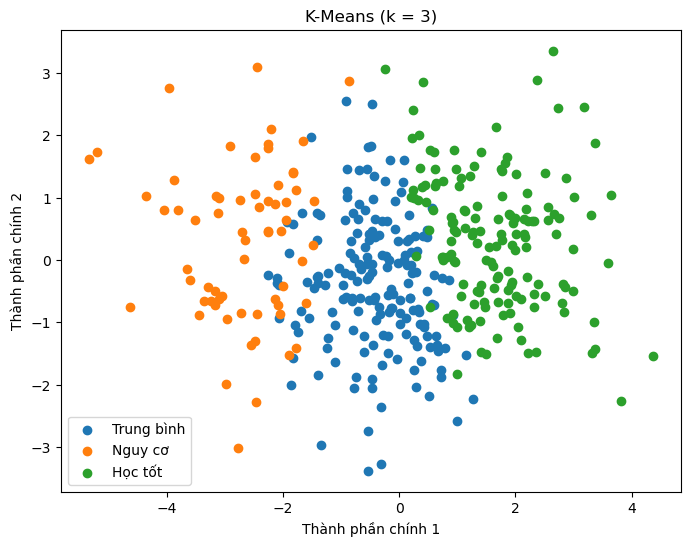

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv')

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA để trực quan hóa
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 5. K-Means với k=3
# =========================
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

# =========================
# 6. Tính trung bình G3
# để đặt tên cụm
# =========================
mean_g3 = df.groupby("Cluster")["G3"].mean().sort_values()

mapping = {}

mapping[mean_g3.index[0]] = "Nguy cơ"
mapping[mean_g3.index[1]] = "Trung bình"
mapping[mean_g3.index[2]] = "Học tốt"

df["TenCum"] = df["Cluster"].map(mapping)

# =========================
# 7. Bảng thống kê cụm
# =========================
cluster_stats = df.groupby("TenCum")[
    [
        "G1",
        "G2",
        "G3",
        "failures",
        "absences",
        "studytime"
    ]
].mean()

# làm tròn 2 chữ số
cluster_stats = cluster_stats.round(2)

print("\n===== THỐNG KÊ TRUNG BÌNH CÁC CỤM =====")
print(cluster_stats)

# =========================
# 8. Thống kê số lượng SV
# =========================
cluster_count = df["TenCum"].value_counts()

print("\n===== SỐ LƯỢNG SINH VIÊN =====")
print(cluster_count)

# =========================
# 9. Vẽ biểu đồ phân cụm
# =========================
plt.figure(figsize=(8,6))

for cluster_name in df["TenCum"].unique():

    plt.scatter(
        X_pca[df["TenCum"] == cluster_name, 0],
        X_pca[df["TenCum"] == cluster_name, 1],
        label=cluster_name
    )

plt.title("K-Means (k = 3)")
plt.xlabel("Thành phần chính 1")
plt.ylabel("Thành phần chính 2")
plt.legend()
plt.show()

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv("E:/student-mat.csv")

# =========================
# 2. Chọn thuộc tính
# =========================
features = [
    "G1", "G2", "G3",
    "studytime", "failures",
    "absences", "goout",
    "freetime", "health"
]

X = df[features]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. K-Means (k=3)
# =========================
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

# =========================
# 5. Tính G3 trung bình
# để xác định tên cụm
# =========================
mean_g3 = (
    df.groupby("Cluster")["G3"]
    .mean()
    .sort_values()
)

cluster_names = [
    "Nguy cơ",
    "Trung bình",
    "Học tốt"
]

mapping = {}

for i, cluster_id in enumerate(mean_g3.index):
    mapping[cluster_id] = cluster_names[i]

df["TenCum"] = df["Cluster"].map(mapping)

# =========================
# 6. Thống kê số lượng SV
# =========================
print("\nSỐ LƯỢNG SINH VIÊN TRONG MỖI CỤM")
print(df["TenCum"].value_counts())

# =========================
# 7. Bảng giá trị trung bình
# các thuộc tính theo cụm
# =========================
cluster_stats = (
    df.groupby("TenCum")[
        [
            "G1",
            "G2",
            "G3",
            "studytime",
            "failures",
            "absences",
            "goout",
            "freetime",
            "health"
        ]
    ]
    .mean()
    .round(2)
)

print("\nGIÁ TRỊ TRUNG BÌNH CÁC THUỘC TÍNH")
print(cluster_stats)

# =========================
# 8. Xuất Excel
# =========================
cluster_stats.to_excel(
    "Bang_Thong_Ke_Cac_Cum.xlsx"
)

print("\nĐã xuất file Bang_Thong_Ke_Cac_Cum.xlsx")

E:\ANCONDA\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



SỐ LƯỢNG SINH VIÊN TRONG MỖI CỤM
TenCum
Trung bình    178
Học tốt       152
Nguy cơ        65
Name: count, dtype: int64

GIÁ TRỊ TRUNG BÌNH CÁC THUỘC TÍNH
               G1     G2     G3  studytime  failures  absences  goout  \
TenCum                                                                  
Học tốt     14.30  14.27  14.46       2.11      0.10      4.39   2.96   
Nguy cơ      7.17   5.71   4.09       1.60      1.51      4.32   3.60   
Trung bình   9.38   9.51   9.27       2.13      0.11      7.34   3.06   

            freetime  health  
TenCum                        
Học tốt         3.34    3.59  
Nguy cơ         3.45    3.89  
Trung bình      3.07    3.40  

Đã xuất file Bang_Thong_Ke_Cac_Cum.xlsx
